# 04 — SAITS-FFT: adaptação do SAITS com condicionamento espectral

**Contribuição proposta.** Partimos do SAITS (Du, Côté & Liu, *"SAITS: Self-attention-based
imputation for time series"*, Expert Systems with Applications, 2023) e o adaptamos assim:

| Ingrediente | SAITS original | Este trabalho |
|---|---|---|
| Atenção com diagonal mascarada (DMSA) | ✔ | ✔ (mantido) |
| Perda conjunta MIT + ORT | ✔ (MAE) | ✔ (MSE, p/ comparação controlada com o BERT) |
| 2º bloco DMSA + combinação ponderada | ✔ | ✘ — substituído pelo **token espectral [FREQ]** |

O token **[FREQ]** é a rFFT da parte visível da janela (posições mascaradas = 0 = média,
pois a série é z-score), projetada em um token extra prefixado à sequência, que todas as
posições podem atender. **Motivação:** na imputação de *blocos* longos o contexto local
desaparece — o que resta é a estrutura periódica global (ciclos de 24 h/168 h, dominantes
em carga elétrica). A atenção teria de aprender essa periodicidade implicitamente; a FFT
a entrega explicitamente, com custo O(L log L) e uma única projeção de parâmetros extras.
O próprio artigo do SAITS admite que empilhar mais blocos DMSA traz ganho marginal —
trocamos essa profundidade extra por informação espectral, ficando com uma arquitetura
**mais simples** que a original.

**Desenho experimental (ablação incluída).** Treinamos duas variantes com o MESMO
orçamento do `BERTImputador` (d_model 64, 3 camadas, 4 cabeças, 40 épocas, semente 42):

1. **SAITS (DMSA+ORT)** — só a adaptação do SAITS, *sem* FFT (`usar_fft=False`) → isola o
   efeito da contribuição espectral;
2. **SAITS-FFT (proposto)** — a contribuição completa.

Ambas são avaliadas no protocolo do notebook 03 (máscaras semente 123, 6 cenários,
mesmos baselines) e comparadas ao BERT já treinado (`resultados/melhor_modelo.pt`,
que **não** é sobrescrito). Novos artefatos: `resultados/saits_base/`,
`resultados/saits_fft/` e `resultados/metricas_saits.{csv,json}`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, TINTA_2, DESTAQUE_MASCARA
from src.saits_fft import SAITSFFT, carregar_saits
from src.modelo import BERTImputador
from src.treino import treinar, fixar_semente, perda_mit_ort, carregar_modelo
from src.avaliacao import avaliar_metodos, imputar_bert_lotes
from src.mascaramento import mascaras_avaliacao, trechos_mascarados

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


## Configuração

Hiperparâmetros idênticos aos do notebook 02 (mesmo encoder, mesmas máscaras de treino,
mesma semente). A única diferença de treino é a perda: `perda_mit_ort` (MIT + ORT do
SAITS) em vez de só MIT — a validação/early stopping continua medindo **apenas MIT**
(MSE nas posições mascaradas), então as curvas de validação dos três modelos são
diretamente comparáveis.

In [2]:
CFG = {
    "semente": 42,
    "epocas": 40,
    "batch": 256,
    "lr": 1e-3,
    "paciencia": 6,          # early stopping
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
    "modelo": {"seq_len": 168, "d_model": 64, "n_camadas": 3, "n_cabecas": 4,
               "d_ff": 256, "dropout": 0.1},
}

def n_parametros(m):
    return sum(p.numel() for p in m.parameters())

print(f"BERT (notebook 02)  : {n_parametros(BERTImputador()):,} parâmetros")
print(f"SAITS (DMSA+ORT)    : {n_parametros(SAITSFFT(**CFG['modelo'], usar_fft=False)):,} parâmetros")
print(f"SAITS-FFT (proposto): {n_parametros(SAITSFFT(**CFG['modelo'], usar_fft=True)):,} parâmetros")

BERT (notebook 02)  : 150,401 parâmetros
SAITS (DMSA+ORT)    : 150,337 parâmetros
SAITS-FFT (proposto): 170,881 parâmetros


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Treinamento das duas variantes

Cada treino fixa a semente antes de instanciar o modelo (inicialização reprodutível) e
salva `melhor_modelo.pt` + `historico.json` na sua própria pasta.

In [3]:
%%time
# variante de ablação: adaptação do SAITS SEM o token espectral
fixar_semente(CFG["semente"])
saits_base = SAITSFFT(**CFG["modelo"], usar_fft=False)
hist_base = treinar(saits_base, ds_treino, ds_val, CFG, device,
                    "resultados/saits_base", fn_perda=perda_mit_ort)

época   1 | treino 0.4116 | val 0.1895  <- melhor


época   2 | treino 0.1729 | val 0.1155  <- melhor


época   3 | treino 0.1295 | val 0.0949  <- melhor


época   4 | treino 0.1126 | val 0.0836  <- melhor


época   5 | treino 0.1024 | val 0.0788  <- melhor


...

época  36 | treino 0.0655 | val 0.0595  <- melhor


época  37 | treino 0.0669 | val 0.0593  <- melhor


época  38 | treino 0.0664 | val 0.0595


época  39 | treino 0.0656 | val 0.0596


época  40 | treino 0.0666 | val 0.0594
CPU times: total: 16min 20s
Wall time: 15min 37s


In [4]:
%%time
# contribuição completa: DMSA + ORT + token espectral [FREQ]
fixar_semente(CFG["semente"])
saits_fft = SAITSFFT(**CFG["modelo"], usar_fft=True)
hist_fft = treinar(saits_fft, ds_treino, ds_val, CFG, device,
                   "resultados/saits_fft", fn_perda=perda_mit_ort)

C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


época   1 | treino 0.3989 | val 0.1792  <- melhor


época   2 | treino 0.1779 | val 0.1239  <- melhor


época   3 | treino 0.1351 | val 0.0947  <- melhor


época   4 | treino 0.1155 | val 0.0856  <- melhor


...

época  36 | treino 0.0661 | val 0.0593  <- melhor


época  37 | treino 0.0671 | val 0.0594


época  38 | treino 0.0669 | val 0.0593


época  39 | treino 0.0661 | val 0.0593


época  40 | treino 0.0671 | val 0.0592  <- melhor
CPU times: total: 15min 30s
Wall time: 14min 47s


BERT (proposto)        melhor val (MIT): 0.0583  (época 40)
SAITS (DMSA+ORT)       melhor val (MIT): 0.0593  (época 37)
SAITS-FFT (proposto)   melhor val (MIT): 0.0592  (época 40)


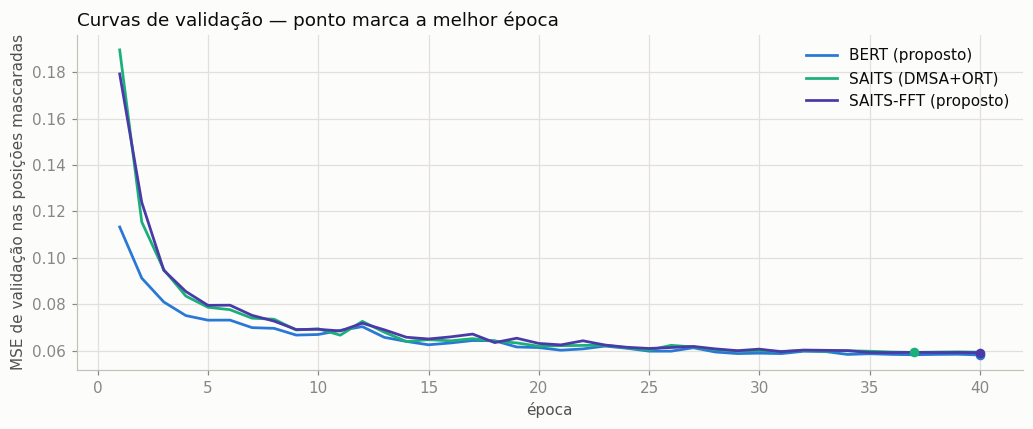

In [5]:
# curvas de validação (todas = MSE só nas posições mascaradas → comparáveis)
with open("resultados/historico.json", encoding="utf-8") as f:
    hist_bert = json.load(f)

CORES_MODELOS = {
    "BERT (proposto)": PALETA["azul"],
    "SAITS (DMSA+ORT)": PALETA["verde_agua"],
    "SAITS-FFT (proposto)": PALETA["violeta"],
}
historicos = {
    "BERT (proposto)": hist_bert,
    "SAITS (DMSA+ORT)": hist_base,
    "SAITS-FFT (proposto)": hist_fft,
}

fig, eixo = plt.subplots(figsize=(9.5, 4))
for nome, hist in historicos.items():
    val = [h["perda_val"] for h in hist]
    eixo.plot(range(1, len(val) + 1), val, color=CORES_MODELOS[nome], label=nome)
    melhor = int(np.argmin(val))
    eixo.scatter(melhor + 1, val[melhor], s=28, color=CORES_MODELOS[nome], zorder=3)
    print(f"{nome:22s} melhor val (MIT): {min(val):.4f}  (época {melhor + 1})")
eixo.set_xlabel("época")
eixo.set_ylabel("MSE de validação nas posições mascaradas")
eixo.set_title("Curvas de validação — ponto marca a melhor época", loc="left")
eixo.legend()
fig.tight_layout()
plt.show()

## Avaliação no conjunto de teste

Mesmo protocolo do notebook 03: máscaras determinísticas (semente 123), 6 cenários
(pontual/bloco × 10/25/50 %), métricas apenas nas posições mascaradas, baselines
clássicos incluídos. O BERT avaliado é o checkpoint original do notebook 02.

In [6]:
%%time
j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")

modelos = {
    "BERT (proposto)": carregar_modelo("resultados/melhor_modelo.pt", device),
    "SAITS (DMSA+ORT)": carregar_saits("resultados/saits_base/melhor_modelo.pt", device),
    "SAITS-FFT (proposto)": carregar_saits("resultados/saits_fft/melhor_modelo.pt", device),
}

cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
resultados = avaliar_metodos(
    j_teste, modelos, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
resultados.to_csv("resultados/metricas_saits.csv", index=False)
resultados.to_json("resultados/metricas_saits.json", orient="records",
                   indent=2, force_ascii=False)
resultados.round(4)

CPU times: total: 43.1 s
Wall time: 21.8 s


,cenário,método,MAE,RMSE,MAE_kW,RMSE_kW,MRE
0,pontual 10%,BERT (proposto),0.1315,0.2067,14.9422,47.6717,0.0446
1,pontual 10%,SAITS (DMSA+ORT),0.1274,0.2024,14.0864,45.6174,0.0421
2,pontual 10%,SAITS-FFT (proposto),0.1324,0.2086,14.9058,47.8461,0.0445
3,pontual 10%,média da janela,0.7789,0.9239,106.8868,308.9570,0.3194
4,pontual 10%,último valor (ffill),0.2929,0.4686,35.6964,145.3564,0.1067
5,pontual 10%,interpolação linear,0.1841,0.2884,21.5006,78.1609,0.0642
6,pontual 25%,BERT (proposto),0.1373,0.2114,15.3225,47.0040,0.0459
7,pontual 25%,SAITS (DMSA+ORT),0.1335,0.2077,14.7446,46.1952,0.0441
8,pontual 25%,SAITS-FFT (proposto),0.1370,0.2125,15.1505,47.4455,0.0454
9,pontual 25%,média da janela,0.7808,0.9250,106.7318,306.4373,0.3195


In [7]:
# MAE por cenário (z-score) e melhora relativa do SAITS-FFT sobre o BERT
nomes_cen = [c[0] for c in cenarios]
tabela_mae = resultados.pivot(index="cenário", columns="método", values="MAE").loc[nomes_cen]
comparacao = tabela_mae[list(modelos)].copy()
comparacao["Δ% FFT vs BERT"] = (
    100 * (comparacao["SAITS-FFT (proposto)"] - comparacao["BERT (proposto)"])
    / comparacao["BERT (proposto)"]
)
comparacao["Δ% FFT vs SAITS s/ FFT"] = (
    100 * (comparacao["SAITS-FFT (proposto)"] - comparacao["SAITS (DMSA+ORT)"])
    / comparacao["SAITS (DMSA+ORT)"]
)
comparacao.round(4)

método,BERT (proposto),SAITS (DMSA+ORT),SAITS-FFT (proposto),Δ% FFT vs BERT,Δ% FFT vs SAITS s/ FFT
cenário,,,,,
pontual 10%,0.1315,0.1274,0.1324,0.6912,3.9685
pontual 25%,0.1373,0.1335,0.1370,-0.1953,2.6214
pontual 50%,0.1558,0.1522,0.1573,0.9631,3.3489
bloco 10%,0.1727,0.1722,0.1749,1.2866,1.5667
bloco 25%,0.1756,0.1755,0.1771,0.8052,0.8807
bloco 50%,0.1877,0.1873,0.1903,1.4005,1.6063


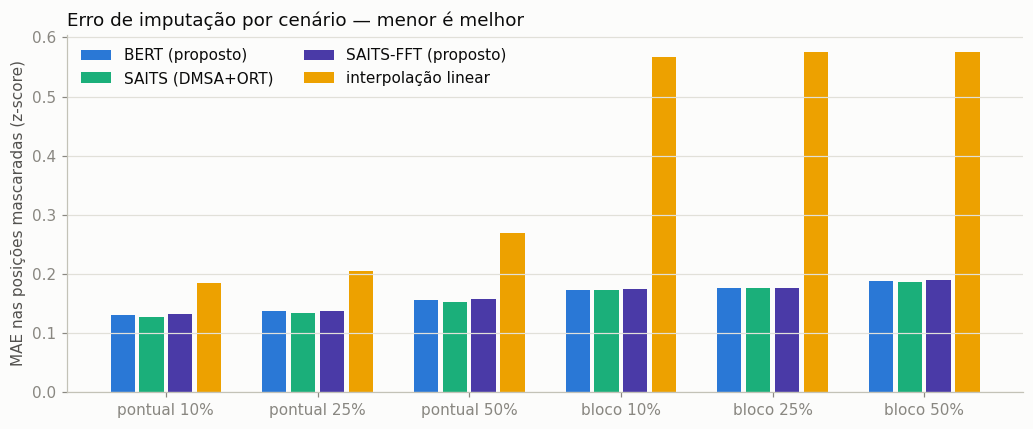

In [8]:
# barras agrupadas: modelos + melhor baseline como referência
ordem = list(modelos) + ["interpolação linear"]
cores = {**CORES_MODELOS, "interpolação linear": PALETA["amarelo"]}
x = np.arange(len(nomes_cen))
larg = 0.19

fig, eixo = plt.subplots(figsize=(9.5, 4))
for k, met in enumerate(ordem):
    v = tabela_mae.loc[nomes_cen, met].to_numpy()
    eixo.bar(x + (k - 1.5) * larg, v, width=larg - 0.03, color=cores[met], label=met)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("Erro de imputação por cenário — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Exemplo qualitativo

Janela de teste com falha em blocos a 50 % — o cenário mais difícil, onde a hipótese
prevê o maior ganho do token espectral (faixas cinzas = trechos escondidos dos modelos).

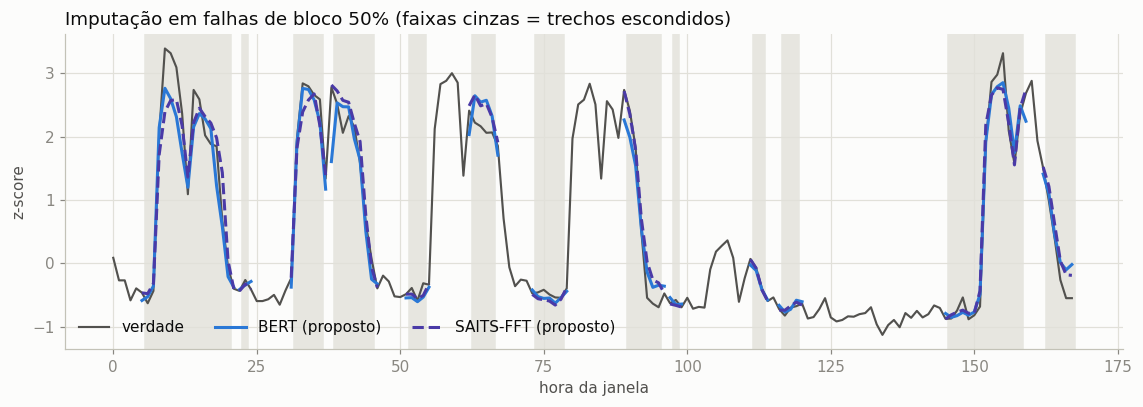

In [9]:
idx_exemplo = 17
x_ex = torch.from_numpy(j_teste[idx_exemplo : idx_exemplo + 1])
masc = mascaras_avaliacao(1, x_ex.shape[1], "bloco", 0.50, semente=7)
imput_bert = imputar_bert_lotes(modelos["BERT (proposto)"], x_ex, masc, device)[0].numpy()
imput_fft = imputar_bert_lotes(modelos["SAITS-FFT (proposto)"], x_ex, masc, device)[0].numpy()

m = masc[0].numpy()
t = np.arange(x_ex.shape[1])
fig, eixo = plt.subplots(figsize=(10.5, 3.8))
for ini, fim in trechos_mascarados(m):
    eixo.axvspan(ini - 0.5, fim - 0.5, color=DESTAQUE_MASCARA, zorder=0)
eixo.plot(t, x_ex[0], color=TINTA_2, linewidth=1.4, label="verdade")
primeiro = trechos_mascarados(m)[0][0]
for ini, fim in trechos_mascarados(m):
    tr = slice(max(ini - 1, 0), min(fim + 1, len(t)))
    eixo.plot(t[tr], imput_bert[tr], color=PALETA["azul"], linewidth=2.0,
              label="BERT (proposto)" if ini == primeiro else None)
    eixo.plot(t[tr], imput_fft[tr], color=PALETA["violeta"], linewidth=2.0, linestyle="--",
              label="SAITS-FFT (proposto)" if ini == primeiro else None)
eixo.set_xlabel("hora da janela")
eixo.set_ylabel("z-score")
eixo.set_title("Imputação em falhas de bloco 50% (faixas cinzas = trechos escondidos)", loc="left")
eixo.legend(ncols=3)
fig.tight_layout()
plt.show()

In [10]:
# resumo numérico: média por tipo de cenário e ganho relativo
resumo = []
for tipo in ("pontual", "bloco"):
    sel = [c for c in nomes_cen if c.startswith(tipo)]
    linha = {"tipo": tipo}
    for met in modelos:
        linha[met] = tabela_mae.loc[sel, met].mean()
    linha["Δ% FFT vs BERT"] = 100 * (linha["SAITS-FFT (proposto)"] - linha["BERT (proposto)"]) / linha["BERT (proposto)"]
    resumo.append(linha)
resumo = pd.DataFrame(resumo).set_index("tipo")
resumo.round(4)

,BERT (proposto),SAITS (DMSA+ORT),SAITS-FFT (proposto),Δ% FFT vs BERT
tipo,,,,
pontual,0.1415,0.1377,0.1422,0.5044
bloco,0.1787,0.1783,0.1807,1.1687


## Diagnóstico: o modelo usa o token espectral?

Ablação **em inferência** (sem retreinar): trocamos o espectro real que alimenta o token
[FREQ] por (a) zeros e (b) o espectro de outra janela do mesmo lote. Se o desempenho não
mudar, o modelo aprendeu a ignorar o token; se degradar, o token é usado de fato — e a
comparação com a variante sem FFT diz se essa informação é *nova* ou apenas redundante
com o que a atenção já extrai do contexto.

In [11]:
import src.saits_fft as sf

espectro_original = sf.caracteristicas_espectrais
modelo_fft = modelos["SAITS-FFT (proposto)"]
x_teste = torch.from_numpy(np.ascontiguousarray(j_teste, dtype="float32"))

def _mae_com_espectro(fn_espectro):
    sf.caracteristicas_espectrais = fn_espectro
    try:
        maes = {}
        for nome_c, tipo, razao in cenarios:
            masc_d = mascaras_avaliacao(len(x_teste), x_teste.shape[1], tipo, razao, semente=123)
            pred = imputar_bert_lotes(modelo_fft, x_teste, masc_d, device)
            maes[nome_c] = (pred - x_teste)[masc_d].abs().mean().item()
        return maes
    finally:
        sf.caracteristicas_espectrais = espectro_original

g = torch.Generator().manual_seed(0)
diagnostico = pd.DataFrame({
    "espectro real": _mae_com_espectro(espectro_original),
    "token zerado": _mae_com_espectro(lambda xv: torch.zeros_like(espectro_original(xv))),
    # permutação dentro do lote: cada janela recebe o espectro de OUTRA janela
    "espectro trocado": _mae_com_espectro(
        lambda xv: espectro_original(xv)[torch.randperm(xv.shape[0], generator=g)]
    ),
})
diagnostico.index.name = "cenário"
diagnostico.to_json("resultados/saits_fft/diagnostico_token.json",
                    orient="index", indent=2, force_ascii=False)
diagnostico.round(4)

,espectro real,token zerado,espectro trocado
cenário,,,
pontual 10%,0.1324,0.1368,0.1340
pontual 25%,0.1370,0.1417,0.1389
pontual 50%,0.1573,0.1622,0.1595
bloco 10%,0.1749,0.1888,0.1811
bloco 25%,0.1771,0.1919,0.1844
bloco 50%,0.1903,0.2038,0.1974


## Conclusões

**O resultado melhorou em relação ao BERT?**

- **SAITS (DMSA+ORT) — a adaptação simplificada do SAITS, *sem* FFT: sim, de forma
  consistente.** MAE menor que o BERT nos 6 cenários (pontual: −3,1 %, −2,8 %, −2,3 %;
  bloco: −0,3 %, −0,1 %, −0,2 %), e também melhor em MAE_kW e MRE em todos, com o
  **mesmo** número de parâmetros (150,3k vs 150,4k) e treino idêntico. O RMSE melhora
  nos cenários pontuais e piora marginalmente nos de bloco (até +0,9 %).
- **SAITS-FFT (token espectral): não.** Fica ~0,5 % (pontual) a ~1,2 % (bloco) atrás do
  BERT em MAE, e atrás da própria ablação em **todos** os cenários (+0,9 % a +4,0 %).
  Na validação os três modelos empatam (0,0583 / 0,0593 / 0,0592).

**Por que o token espectral não ajudou?** O diagnóstico acima mostra que o modelo
treinado *depende* do token: zerá-lo degrada o MAE em +7–8 % nos blocos e +3 % nos
pontuais, e dar-lhe o espectro de outra janela também degrada (+4 % nos blocos) — o
token carrega, portanto, informação específica da janela e é efetivamente usado. Ainda
assim, a variante sem FFT alcança desempenho igual ou melhor extraindo a mesma
informação diretamente do contexto via atenção. Em janelas de 168 h com periodicidade
forte (ciclos de 24 h/168 h) e 50–90 % dos pontos visíveis, o espectro é **redundante**:
o encoder o reconstrói sozinho, e o modelo com token apenas "terceiriza" essa
informação sem ganho líquido. A hipótese de ganho nos blocos não se confirmou.

**Leitura para a contribuição.** O ganho consistente veio dos ingredientes do SAITS que
mantivemos — a perda conjunta MIT+ORT (gradiente em 100 % das posições de cada lote, e
não só nas ~25 % mascaradas) sobre um **único** bloco DMSA. Isso caracteriza um
*SAITS simplificado*: mais simples que o original (sem o 2º bloco e sem a combinação
ponderada) e melhor que o BERT sob o mesmo orçamento. O token [FREQ] fica documentado
como ablação com resultado negativo, acompanhada do diagnóstico que explica o porquê —
em séries fortemente periódicas amostradas em janelas longas, informação espectral
explícita é redundante com o que a autoatenção bidirecional já captura.

**Ressalvas.** As diferenças são pequenas (1–3 %) e vêm de uma única semente (42);
conclusões fortes pedem repetição com múltiplas sementes. As máscaras de avaliação
determinísticas (semente 123) garantem que os números acima são exatamente
reprodutíveis.

**Artefatos gerados** (nada do BERT foi sobrescrito): `resultados/saits_base/` e
`resultados/saits_fft/` (checkpoints + históricos), `resultados/metricas_saits.{csv,json}`
e `resultados/saits_fft/diagnostico_token.json`.